Shared imports/ project setup

In [10]:
# Standard Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings

# Scikit-Learn: Datasets
from ucimlrepo import fetch_ucirepo

# Scikit-Learn: Preprocessing, Imputation, & Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Scikit-Learn: Model Selection, Evaluation, & Visualization
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import NearestCentroid
from sklearn.neural_network import MLPClassifier

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid


In [11]:
#SETUP/ PREPROCESSING

warnings.filterwarnings("ignore")

print("Fetching UCI Diabetes Dataset...")
diabetes = fetch_ucirepo(name='Diabetes 130-US Hospitals for Years 1999-2008') # previously df
X = diabetes.data.features
y = diabetes.data.targets['readmitted']

# Encode target (readmission). 
# readmitted {0: '<30', 1: '>30', 2: 'NO'}
y = y.values.ravel()
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Handle missing data
X = X.replace('?', np.nan) # replace ? with NaN

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# preprocess data for use across all models
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ])

print("Applying Preprocessing Pipeline...")
X_preprocessed = preprocessor.fit_transform(X)

Fetching UCI Diabetes Dataset...
Applying Preprocessing Pipeline...


In [12]:
# create data split based on project overview, section 4 experimental setup

seed = 1234
np.random.seed(seed)

# 60% Test Split
X_temp, X_te, y_temp, y_te = train_test_split(
    X_preprocessed, y_encoded, test_size=0.60, random_state=seed, stratify=y_encoded
)

# Split remaining 40% into 20% Train and 20% Validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp)

In [13]:
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [14]:
#y.head()
y_encoded[:5]

array([2, 1, 2, 2, 2])

Linear Regression

Nearest Centroid

MLP 

In [15]:
# # hypertuning params, from hw3

# tuning_results = []
# mlp_loss_curves = {}

# lr_options = [0.001, 0.005]
# hidden_options = [(256,), (512,)]
# alpha_options = [0.0001, 0.01]
# activation_options = ['relu']
# batch_options = [32, 64]

# combinations = itertools.product(lr_options, hidden_options, alpha_options, activation_options, batch_options)

# for lr, hidden, alpha, activation, batch in combinations:
#     config = {
#         'learning_rate_init' : lr,
#         'hidden_layer_sizes' : hidden,
#         'alpha' : alpha,
#         'activation' : activation,
#         'solver' : 'sgd',
#         'batch_size' : batch,
#         'random_state' : seed,
#         # limit our model bc the dataset is larger than hw ds have been
#         'max_iter': 50,
#         'early_stopping': True, 
#         'n_iter_no_change': 5
#     }

#     mlp = MLPClassifier(**config)
#     mlp.fit(X_tr, y_tr)
#     print(f"Finished tuning: LR={lr}, Hidden={hidden}, Batch={batch} | Epochs run: {mlp.n_iter_}")
    
#     tuning_results.append({
#         'config': config, 
#         'train_acc': mlp.score(X_tr, y_tr),
#         'val_acc': mlp.score(X_val, y_val)
#     })

#     curve_key = f"lr={lr}, batch={batch}"
#     mlp_loss_curves[curve_key] = mlp.loss_curve_


# # Identify the best hyperparameters based on validation accuracy
# final_hyperparameters = max(tuning_results, key=lambda x: x['val_acc'])['config']
# final_hyperparameters['max_iter'] = 100

# # Train final model and evaluate on the test set
# final_model = MLPClassifier(**final_hyperparameters)
# final_test_accuracy = final_model.fit(X_tr, y_tr).score(X_te, y_te)


# print('Number of configurations tried:', len(tuning_results))
# print('Final hyperparameters:', final_hyperparameters)
# print('Final test accuracy:  ', final_test_accuracy)

In [16]:
# # Display results
# tuning_table = pd.DataFrame([
#     {**r['config'], 'train_acc': r['train_acc'], 'val_acc': r['val_acc']}
#     for r in tuning_results
# ])
# tuning_table

In [17]:
# # Learning Loss Convergence
# fig, ax = plt.subplots(figsize=(9, 6))

# # Track the absolute best loss to highlight it
# best_loss = float('inf')
# best_lr = None
# best_epoch = 0

# for lr, loss_history in mlp_loss_curves.items():
#     # Plot each line
#     line, = ax.plot(loss_history, label=f'lr = {lr}', linewidth=2, alpha=0.8)
    
#     # Check if this is the lowest loss we've seen
#     if loss_history[-1] < best_loss:
#         best_loss = loss_history[-1]
#         best_lr = lr
#         best_epoch = len(loss_history) - 1

# # Dashed line marking the lowest loss achieved
# ax.axhline(y=best_loss, color='red', linestyle='--', alpha=0.5, 
#            label=f'Best Final Loss ({best_loss:.3f})')

# # Highly visible dot exactly where the best model finished
# ax.scatter(best_epoch, best_loss, color='red', s=100, zorder=5)

# # Lables
# ax.set_title('MLP Training Loss Convergence by Learning Rate', fontsize=14, fontweight='bold')
# ax.set_xlabel('Epochs (Training Iterations)', fontsize=12)
# ax.set_ylabel('Training Loss', fontsize=12)
# ax.grid(True, linestyle=':', alpha=0.6)
# ax.legend(loc='upper right')

# plt.tight_layout()
# plt.show()

KNN

In [ ]:
from sklearn.model_selection import GridSearchCV
k_range = list(range(5, 101, 5))
weight_options = ['uniform', 'distance']
metric_types = ['minkowski']
p_values = [1, 2]

knn_config = {
    'n_neighbors': k_range,
    'weights': weight_options,
    'metric': metric_types,
    'p': p_values
    }

knn_search = GridSearchCV(
    estimator = KNeighborsClassifier(),
    param_grid = knn_config,
    cv = 3,                  
    scoring = 'accuracy',    
    n_jobs = 24,             
    verbose = 2
)


print("Starting KNN Random Search...")
knn_search.fit(X_tr, y_tr)

print(f"Best Parameters: {knn_search.best_params_}")
print(f"Best CV Score: {knn_search.best_score_:.4f}")

Starting KNN Random Search...
Fitting 3 folds for each of 160 candidates, totalling 480 fits
Best Parameters: {'metric': 'minkowski', 'n_neighbors': 80, 'p': 2, 'weights': 'distance'}
Best CV Score: 0.5707


In [19]:
bestModel=knn_search.best_estimator_
test_prediect=bestModel.predict(X_te)
test_acc=accuracy_score(y_te,test_prediect)

print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_te, test_prediect))

Final Test Accuracy: 56.78%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.00      0.01      6814
           1       0.49      0.24      0.32     21327
           2       0.58      0.90      0.71     32919

    accuracy                           0.57     61060
   macro avg       0.51      0.38      0.35     61060
weighted avg       0.54      0.57      0.49     61060



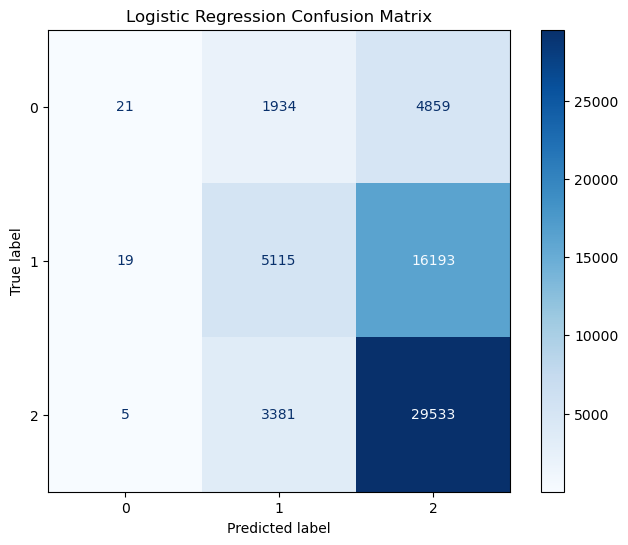

In [20]:
cm = confusion_matrix(y_te, test_prediect, labels=bestModel.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bestModel.classes_)

fig, ax = plt.subplots(figsize=(8, 6)) 
disp.plot(cmap='Blues', ax=ax, values_format='d') 

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [21]:
# k_range = list(range(5, 201, 5))
# weight_options = ['uniform', 'distance']
# metric_types = ['minkowski']
# p_values = [1, 2]

# combinations = itertools.product(k_range, weight_options, metric_types, p_values)
# print(combinations)
# tuning_results=[]
# for k_range, weight_options, metric_types, p_values in combinations:
#     knn_config = {
#     'n_neighbors': k_range,
#     'weights': weight_options,
#     'metric': metric_types,
#     'p': p_values
#     }
    
#     KNN = KNeighborsClassifier(**knn_config)
#     KNN.fit(X_tr, y_tr)
#     print(f"Finished tuning: K={k_range}, weight={weight_options}, metric={metric_types} ,p= {p_values}")
    
#     tuning_results.append({
#         'config': knn_config, 
#         'train_acc': KNN.score(X_tr, y_tr),
#         'val_acc': KNN.score(X_val, y_val)
#     })

#     # curve_key = f"lr={k_range}, batch={weight_options}"
#     # knn_loss_curves[curve_key] = KNN.loss_curve_
    
# print(tuning_results)

Logistic Classifiers

In [22]:

from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

tuning_results = []
mlp_loss_curves = {}

C= [0.001, 0.01, 0.1, 1, 10]
penalty= ['l1', 'l2']
solver= ['liblinear', 'saga']
class_weight= [None, 'balanced']

config={
    'C':C,
    'penalty': penalty,
    'solver': solver, 
    'class_weight':class_weight
    }

random_S = RandomizedSearchCV(
    estimator = LogisticRegression(max_iter=500, tol=0.001, random_state=seed), 
    param_distributions = config,
    n_iter = 15,          
    cv = 3,               
    scoring = 'f1_macro', # was accuracy
    n_jobs = 24,     # number of cores     
    verbose = 2,
    random_state = seed
)

print("Starting Random Search...")
random_S.fit(X_tr, y_tr)

print(f"Best Parameters: {random_S.best_params_}")
print(f"Best Validation Accuracy: {random_S.best_score_:.4f}")

Starting Random Search...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'solver': 'saga', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 0.1}
Best Validation Accuracy: 0.4212


In [23]:
bestModel=random_S.best_estimator_
test_prediect=bestModel.predict(X_te)
test_acc=accuracy_score(y_te,test_prediect)

print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_te, test_prediect))

Final Test Accuracy: 49.56%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.37      0.24      6814
           1       0.46      0.33      0.38     21327
           2       0.65      0.63      0.64     32919

    accuracy                           0.50     61060
   macro avg       0.43      0.44      0.42     61060
weighted avg       0.53      0.50      0.51     61060



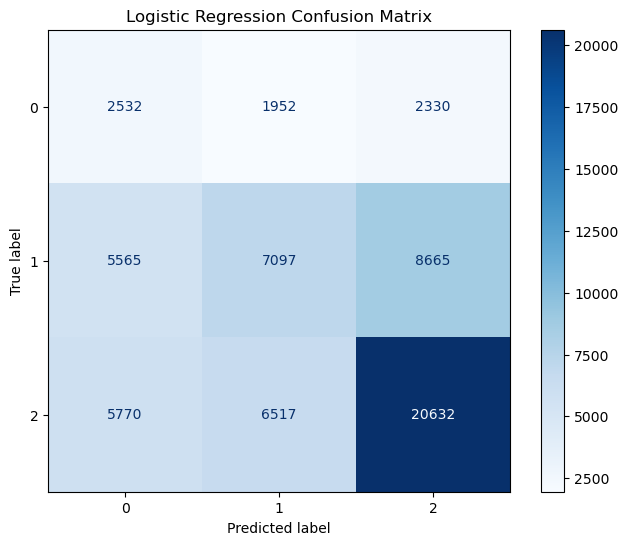

In [24]:
cm = confusion_matrix(y_te, test_prediect, labels=bestModel.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bestModel.classes_)

fig, ax = plt.subplots(figsize=(8, 6)) 
disp.plot(cmap='Blues', ax=ax, values_format='d') 

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Beata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore, “Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,” BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014.